In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the native Seaborn Dow Jones dataset
# It contains columns: Date and Price
df = sns.load_dataset("dowjones")


In [2]:
df


,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12



# 2. Calculate Financial Metrics using Pandas


In [4]:
# Trend: A moving average smoother (e.g., 50-day average)
df["Trend_50MA"] = df["Price"].rolling(window=50).mean()

# Returns: Percentage change from the previous day
df["Daily_Return"] = df["Price"].pct_change()

# Volatility: Rolling standard deviation of returns (e.g., 20-day window)
df["Volatility_20D"] = df["Daily_Return"].rolling(window=20).std()


In [5]:
df

,Date,Price,Trend_50MA,Daily_Return,Volatility_20D
0,1914-12-01,55.00,NaN,NaN,NaN
1,1915-01-01,56.55,NaN,0.028182,NaN
2,1915-02-01,56.00,NaN,-0.009726,NaN
3,1915-03-01,58.30,NaN,0.041071,NaN
4,1915-04-01,66.45,NaN,0.139794,NaN
...,...,...,...,...,...
644,1968-08-01,883.72,883.7910,-0.023859,0.027239
645,1968-09-01,922.80,885.3622,0.044222,0.027720
646,1968-10-01,955.47,887.7656,0.035403,0.028205
647,1968-11-01,964.12,889.7770,0.009053,0.028209


# Stock Price & Trend Lines

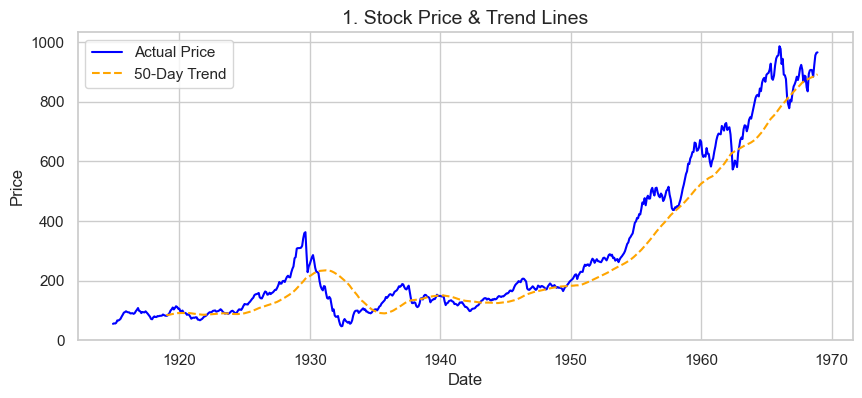

In [7]:
# Set the overall theme once at the start
sns.set_theme(style="whitegrid")

# Create a clean, independent canvas
plt.figure(figsize=(10, 4))

# Plot both lines directly on the main figure
sns.lineplot(data=df, x="Date", y="Price", label="Actual Price", color="blue")
sns.lineplot(data=df, x="Date", y="Trend_50MA", label="50-Day Trend", color="orange", linestyle="--")

# Add titles and labels directly to the plot
plt.title("1. Stock Price & Trend Lines", fontsize=14)
plt.ylabel("Price")
plt.xlabel("Date")
plt.legend()
plt.show()


# Distribution of Daily Returns

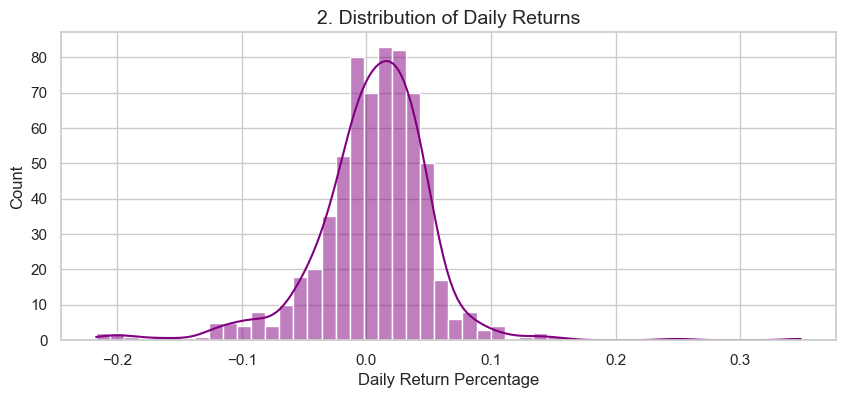

In [8]:
# Create a fresh canvas for the second chart
plt.figure(figsize=(10, 4))

# Plot the distribution histogram directly
sns.histplot(data=df, x="Daily_Return", kde=True, color="purple", bins=50)

# Add title and clean up labels
plt.title("2. Distribution of Daily Returns", fontsize=14)
plt.xlabel("Daily Return Percentage")
plt.ylabel("Count")
plt.show()


# Market Volatility

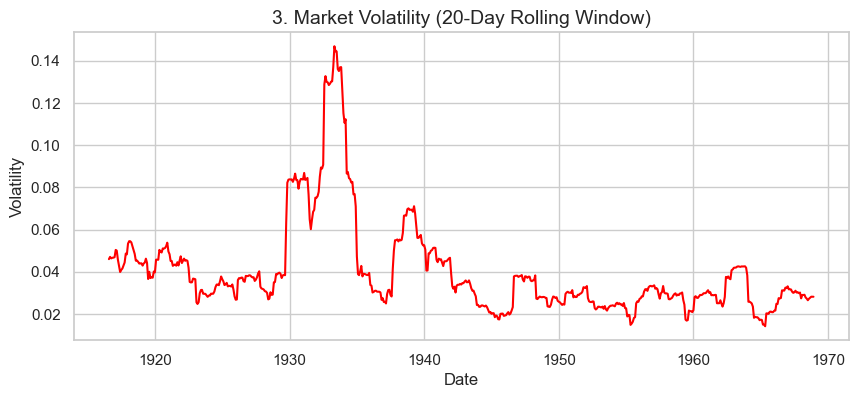

In [9]:
# Create a fresh canvas for the final chart
plt.figure(figsize=(10, 4))

# Plot the rolling volatility line directly
sns.lineplot(data=df, x="Date", y="Volatility_20D", color="red", linewidth=1.5)

# Add title and labels
plt.title("3. Market Volatility (20-Day Rolling Window)", fontsize=14)
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.show()
